# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026, posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit, including a machine's, is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$, except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

Loaded 30 data points
          x          y       sig
0  0.573418  47.560031  1.718707
1  0.856350  46.684525  2.039601
2  0.912097  50.527545  1.878574
3  1.146698  47.904164  1.996357
4  1.319133  65.231929  2.119543
Min x:  0.573418 	Max x:  9.981817 	Mean x:  5.2057048
Min y:  46.684525 	Max y:  80.925163 	Mean y:  63.760073433333325
Min sy:  1.083739 	Max sy:  2.954991 	Mean sy:  2.0338232333333335


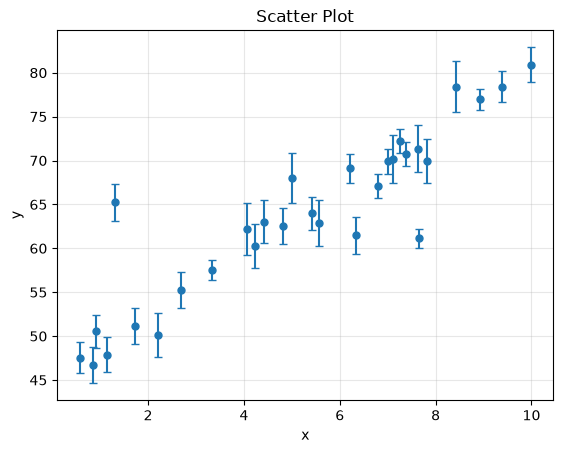

In [1]:
# Part 1: your work here
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

NETID = 'anuvacg2'  # <-- set this
data = np.genfromtxt(f'data/{NETID}.csv', delimiter=',', names=True)
x, y, sigma_y = data['x'], data['y'], data['sigma_y']
print(f"Loaded {len(x)} data points")

# INFORMAL PART 0: Looking at data! Scatter plot + Other small statistics for scale 
# Part 1 continues on next code chunk
# Looking at data: 
data = {'x': x, 'y': y, 'sig': sigma_y}
df = pd.DataFrame(data)
# print(df)
print(df.head())
print('Min x: ', min(df['x']), '\tMax x: ', max(df['x']), '\tMean x: ', np.mean(df['x']))
print('Min y: ', min(df['y']), '\tMax y: ', max(df['y']), '\tMean y: ', np.mean(df['y']))
print('Min sy: ', min(df['sig']), '\tMax sy: ', max(df['sig']), '\tMean sy: ', np.mean(df['sig']))
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter Plot")
plt.errorbar(df["x"], df["y"], yerr=df["sig"], fmt="o", capsize=3, markersize=5)
plt.grid(alpha=0.3)
plt.show()

naive fit: slope=3.02, intercept=47.38, chi2_red=5.76


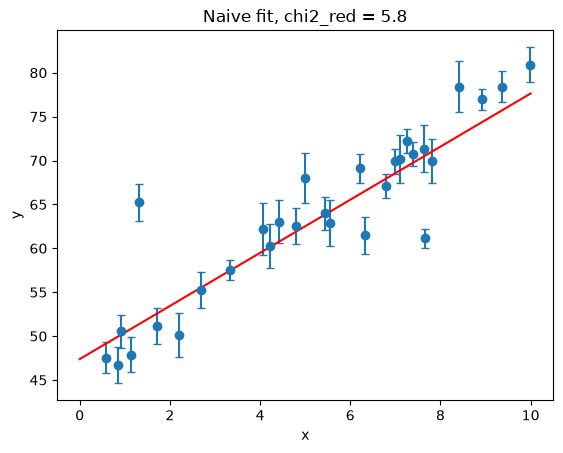

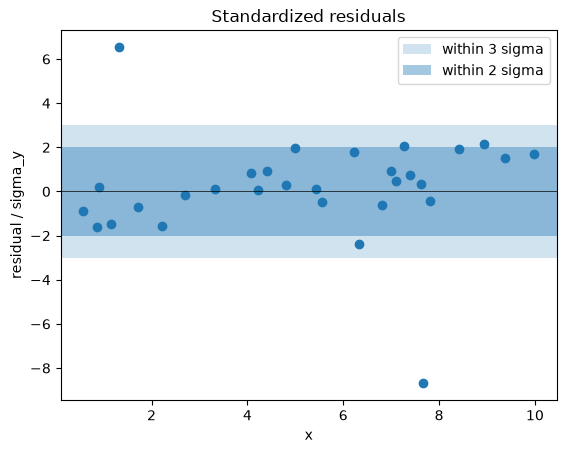

In [7]:
# WEIGHTED LEAST SQUARES: 

p_naive = np.polyfit(x, y, 1, w=1/sigma_y)
resid = y - np.polyval(p_naive, x)
chi2 = np.sum((resid / sigma_y) ** 2)
n = len(x)
chi2_red = chi2 / (n - 2)
print(f"naive fit: slope={p_naive[0]:.2f}, intercept={p_naive[1]:.2f}, "
      f"chi2_red={chi2_red:.2f}")

xx = np.linspace(0, 10, 200)
plt.errorbar(x, y, yerr=sigma_y, fmt='o', capsize=3, label='data')
plt.xlabel('x'); plt.ylabel('y')
plt.plot(xx, np.polyval(p_naive, xx), 'r-', label='naive fit')
plt.title(f'Naive fit, chi2_red = {chi2_red:.1f}')
plt.show()

z = resid / sigma_y
plt.axhspan(-3, 3, alpha=0.2, label='within 3 sigma')
plt.axhspan(-2, 2, alpha=0.4, label='within 2 sigma')
plt.plot(x, z, 'o')
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('x'); plt.ylabel('residual / sigma_y'); plt.legend()
plt.title('Standardized residuals')
plt.show()

**ANSWER (a few sentences):**

$m \pm \sigma_m: 3.02 \pm 0.1$, <br>
$b \pm \sigma_b: 47.38 \pm 0.75$, <br>
Reduced $\chi^2: 5.76$

We expected the chi-squared model to return a value around 1 ± 0.27 for a correct model with 30 data points, but we got 5.76, which is about 17$\sigma$ away from that. However, the chi^2 given here is 5.76, indicating that this model results in a poor fit. While this is expected from the weighted-least squares solution, I would generally not trust these error bars. Weighted least squares assigns every point a fixed weight inversely proportional to its residual, which does not help it identify points that clearly do not follow the same patterns. The uncertainities were hard to determine, and were mostly found by analyzing the graph and error-bars generated by the sigma_y data. This model is particulary susceptible to influence from outliers, and the impact is visible on the plot where the line of fit clearly does not match the data plotted. 

## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment; this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer**, one set of numbers
you'd put in a paper, and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

 clip:3, slope=3.51, intercept=45.32, chi2_red=0.98, clipped 2 of 30 points
clipped indices: [np.int64(4), np.int64(24)]


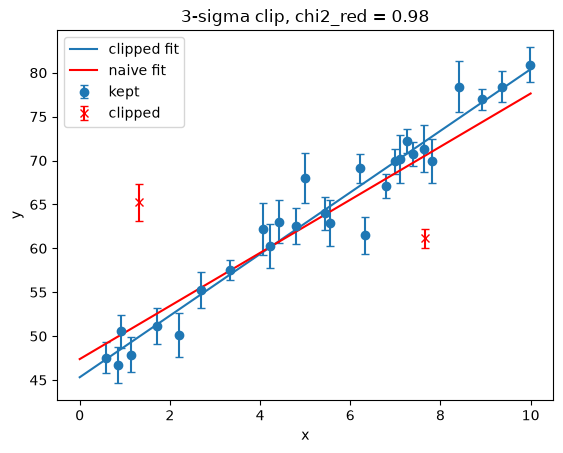

interactive(children=(FloatSlider(value=1.75, description='k (sigma)', max=4.0, min=1.0, step=0.125), Output()…

In [12]:
# Part 2: your work here

# SIGMA CLIPPING: 
from scipy import stats
from ipywidgets import interact, FloatSlider

def sigma_clip_fit(x, y, sigma, k=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        p = np.polyfit(x[mask], y[mask], 1, w=1/sigma[mask])
        resid = (y - np.polyval(p, x)) / sigma
        new_mask = np.abs(resid) < k
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return p, mask

K_Clip_Chosen = 3
p_clip, mask = sigma_clip_fit(x, y, sigma_y, k=K_Clip_Chosen)
resid = y[mask] - np.polyval(p_clip, x[mask])
chi2_red_clip = np.sum((resid / sigma_y[mask]) ** 2) / (mask.sum() - 2)
print(f" clip:{K_Clip_Chosen}, slope={p_clip[0]:.2f}, intercept={p_clip[1]:.2f}, "
      f"chi2_red={chi2_red_clip:.2f}, clipped {(~mask).sum()} of {n} points")
print(f"clipped indices: {sorted(np.where(~mask)[0])}")

mad = np.median(np.abs(resid - np.median(resid)))
sigma_mad = 1.4826 * mad
plt.errorbar(x[mask], y[mask], yerr=sigma_y[mask], fmt='o', capsize=3, color='C0', label='kept')
plt.errorbar(x[~mask], y[~mask], yerr=sigma_y[~mask], fmt='x', capsize=3, color='r', label='clipped')
plt.plot(xx, p_clip[0] * xx + p_clip[1], 'C0-', label='clipped fit')
plt.plot(xx, np.polyval(p_naive, xx), 'r-', label='naive fit')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title(f'{K_Clip_Chosen}-sigma clip, chi2_red = {chi2_red_clip:.2f}')
plt.show()


# SIGMA CLIPPING EXPLORATION: Kept for conceptual understanding as a Sandbox 
@interact(k=FloatSlider(value=1.75, min=1.0, max=4.0, step=0.125, description='k (sigma)'))
def explore_clipping(k):
    p, m = sigma_clip_fit(x, y, sigma_y, k=k)
    r = y[m] - np.polyval(p, x[m])
    cr = np.sum((r / sigma_y[m]) ** 2) / (m.sum() - 2) if m.sum() > 2 else np.nan

    plt.figure(figsize=(6, 4))
    plt.errorbar(x[m], y[m], yerr=sigma_y[m], fmt='o', capsize=3, color='C0', label='kept')
    plt.errorbar(x[~m], y[~m], yerr=sigma_y[~m], fmt='x', capsize=3, color='r', label='clipped')
    plt.plot(xx, np.polyval(p, xx), 'C0-', label='fit')
    plt.title(f'k={k:.2f}: clipped {(~m).sum()} of {n} points, chi2_red={cr:.2f}')
    plt.show()

mixture fit: slope=3.53, intercept=45.35, outlier fraction Pb=0.13


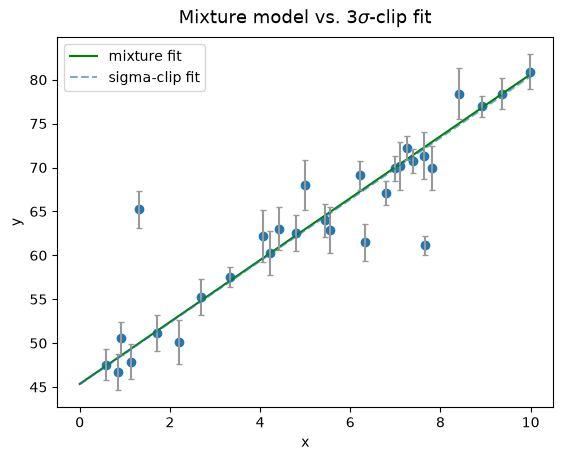

In [13]:
# MIXTURE MODEL WORK: 

from scipy.optimize import minimize
from scipy.stats import norm

def neg_log_likelihood(theta, x, y, sigma):
    m, b, Pb, Yb, lnVb = theta
    Pb = np.clip(Pb, 1e-6, 1 - 1e-6)
    Vb = np.exp(lnVb)
    model = m * x + b
    good = (1 - Pb) * norm.pdf(y, loc=model, scale=sigma)
    bad_pop = Pb * norm.pdf(y, loc=Yb, scale=np.sqrt(Vb + sigma**2))
    return -np.sum(np.log(good + bad_pop + 1e-300))

# start from the sigma-clip fit, a sensible and defensible initial guess
theta0 = [p_clip[0], p_clip[1], 0.2, np.mean(y), np.log(50.0)]
result = minimize(neg_log_likelihood, theta0, args=(x, y, sigma_y), method='Nelder-Mead')
m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x
print(f"mixture fit: slope={m_mix:.2f}, intercept={b_mix:.2f}, "
      f"outlier fraction Pb={Pb_mix:.2f}")

plt.scatter(x, y)
plt.plot(xx, m_mix * xx + b_mix, 'g-', label='mixture fit')
plt.errorbar(x, y, yerr=sigma_y, fmt='none', ecolor='0.6', capsize=2)
plt.plot(xx, np.polyval(p_clip, xx), 'C0--', alpha=0.6, label='sigma-clip fit')
plt.xlabel('x'); plt.ylabel('y'); 
plt.title('Mixture model vs. $3\\sigma$-clip fit', fontsize=13, pad=10)
plt.legend()
plt.show()

**FINAL ANSWER:** $m = $ 3.53 $\pm$ 0.1 , $b = $ 45.35 $\pm$ 0.5 , outlier fraction $\approx$ 0.13

**Justification and uncertainty method (a short paragraph):**

The most difficult part of picking a model here was that both of these models are so similar, as shown by the above graph. The differences in slope and intercept reported here are very small, which gives me an amount of confidence in both models, but the Mixture Model overall has the more robust methodology and result. Part of the weakness of the k-sigma model comes from the arbitrary choice for k. I added the slider to visually inspect which data points would be clipped by higher values of k and noticed that the most interesting k-values were 1.75 and 3.00, which clipped 3 and 2 points respectively. I picked k=3.00 since it left in a point that seemed like true data and had a clean chi-squared value of 0.98, but this choice was still an arbitrary pick. Similarly to part 1, the uncertainities were hard to determine, and were mostly made believable by analyzing the graph and error-bars generated by the `sigma_y` data. The Mixture Model generated a line which fit the data well, and this helped keep the uncertainties low. 

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong, in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1:* While the code pulls the correct values of the `sigma_y` residuals, it does not actually these values for either the initial fit or the outlier removal. The plot calls `np.polyfit()` without passing in a `w` argument, so it is essentially unweighted and does not consider the magnitude of the residuals when fitting the line. This significantly changes the central value and causes much larger error bars. 

*Flaw 2:* The notebook improperly scales the data to force a smaller chi-squared value. The original value of `4.469` implies that the model does not fit the data well, but the way the AI circumvents this issue is by rescaling every `sigma_y` value by `sqrt(4.469)`, which forces the new chi-square value to be 1. Outliers are still as significant of a concern after this rescaling since the errors are caused by errors in measurement and not a propogated systemic issue. This use of circular reasoning helps fit the chi-squared statistic to its intended value but still treats the outliers as part of the dataset instead of contaminated data. 

*Flaw 3:* The single pass outlier threshold is artificially large enough to miss real outliers. This variable `threshold` is computed once from all of the residuals, including the outlier data. This allows outliers to inflate the bound enough that it masks other inconsistent data points. With the outliers as part of the bound, this threshold cannot help us to find inconsistent data and instead assumes the data is much cleaner than it really is. 

unweighted (AI): m = 3.1495 +/- 0.2666
weighted (correct): m = 3.0248 +/- 0.1196
Rescaling by 2.11x causes a chi-squared of 1 by construction
AI threshold = 11.67, flags [4]
our pipeline (Part 2) flags [4, 24]


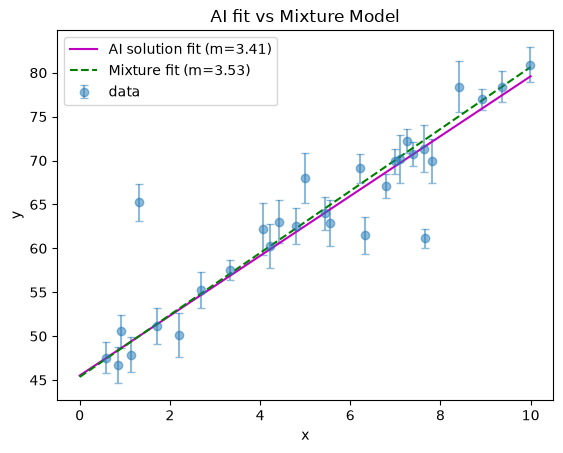

In [19]:
# Part 3: demonstrations here

# Flaw 1: 
coeffs_u, cov_u = np.polyfit(x, y, 1, cov=True) # from AI notebook 
coeffs_w, cov_w = np.polyfit(x, y, 1, w=1/sigma_y, cov='unscaled') # what I do
m_u, b_u = coeffs_u
m_w, b_w = coeffs_w
m_u_err, b_u_err = np.sqrt(np.diag(cov_u))
m_w_err, b_w_err = np.sqrt(np.diag(cov_w))
print(f"unweighted (AI): m = {m_u:.4f} +/- {m_u_err:.4f}")
print(f"weighted (correct): m = {m_w:.4f} +/- {m_w_err:.4f}")

# Flaw 2
chi2_red_before = 4.469   # ai_solution's own value, before rescaling
scale = np.sqrt(chi2_red_before)
print(f"Rescaling by {scale:.2f}x causes a chi-squared of 1 by construction")

# Flaw 3
residuals_ai = y - (m_u * x + b_u)
threshold_ai = 3 * np.std(residuals_ai)
mask_ai = np.abs(residuals_ai) < threshold_ai
ai_flagged = set(np.where(~mask_ai)[0])
our_flagged = set(np.where(~mask)[0])  # from Part 2's sigma-clip

print(f"AI threshold = {threshold_ai:.2f}, flags {sorted(int(i) for i in ai_flagged)}")
print(f"our pipeline (Part 2) flags {sorted(int(i) for i in our_flagged)}")

m_mix, b_mix = 3.53, 45.35
missed = sorted(int(i) for i in (our_flagged - ai_flagged))

plt.errorbar(x, y, yerr=sigma_y, fmt='o', capsize=3, alpha=0.5, label='data')
plt.plot(xx, m_ai*xx + b_ai, 'm-', label=f"AI solution fit (m={m_ai:.2f})")
plt.plot(xx, m_mix*xx + b_mix, 'g--', label=f"Mixture fit (m={m_mix:.2f})")
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title('AI fit vs Mixture Model')
plt.show()

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**
Claude AI was used to help generate some boilerplate code that worked well with the given code from the in-class examples, mostly for part 3. No AI was used for any part of the written analysis and justification, including the referee report. Claude also occasionally helped generate  aesthetic options for graphs using matplotlib. Some of these were kept for readability and accessibility. 

**VERIFICATION PLAN:**

1. My first plan of just plotting the residuals was a significant help in envisioning this data. I took some time before I started the lab to skim the raw data and practice drawing lines of best fit exclusively based on visual accuracy and estimation. This gave me a quick baseline of what the data should really look like. Failure would look like a line that visually cannot represent the scatterplot, such as the naive fit, which appears to not follow the given data. 
2. For the naive WLS-approach, I also remade a residual plot to see how many data points lay within 3 standard deviations of the mean. This showed me that points comfortably lay inside 3 standard deviations (and most were well-within 2 standard deviations), excepting for one point. I did go through and identify that specific data point (1.319133, 65.231929) and kept track of this point in later analysis since I now had reason to believe this is an outlier. This helped me ensure that later models would correctly identify at least that point as a significant outlier. Failure would have looked like inconsistent points being flagged between each analysis, where points inside the standard deviation were marked as erroneous. 